# Advanced Process Mining Project – Group 1

## Setup

In [57]:
# Import necessary libraries
import numpy as np
import pandas as pd
import os, time, signal, re
import multiprocessing, ctypes

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import to_rgba

from IPython.display import Image, display
from collections import Counter, defaultdict, deque
# from datetime import datetime, timedelta, time

import pm4py
from pm4py.visualization.dfg import visualizer as dfg_visualizer

# Import custom functions for the calculations with timeout
from timeout_workers import _fitness_worker, _precision_worker, _simplicity_worker

# Supress warnings
import warnings
warnings.filterwarnings('ignore') 

In [58]:
# Load the event logs
all_log = pm4py.read_xes('Event Logs/all.xes')
accepted_loans = pm4py.read_xes('Event Logs/accepted-loans.xes')
rejected_loans = pm4py.read_xes('Event Logs/rejected-loans.xes')
lcs_rejected_customers = pm4py.read_xes('Event Logs/lcs-rejected-customers.xes')
mid_rejected_customers = pm4py.read_xes('Event Logs/mid-rejected-customers.xes')
mla_rejected_customers = pm4py.read_xes('Event Logs/mla-rejected-customers.xes')

parsing log, completed traces :: 100%|██████████| 392/392 [00:00<00:00, 1794.60it/s]


## <b>Question 1</b>: Initial Overview
At the beginning of a process mining analysis, it is advisable to obtain an initial overview of the event data.

In [59]:
print(f'Shape: {all_log.shape}')
all_log.head(5)

Shape: (47553, 27)


,concept:name,time:timestamp,org:resource,lifecycle:transition,case:concept:name,case:customer_id,case:customer_name,case:customer_ssid,case:loan_amount,case:case_creation_no,...,loan_decision,loan_decision_extra,interest,loan_term_years,recipient,transfer_amount,repayments,installment_target,repaid_amount,cumulatively_repaid
0,Application Registered,2021-01-03 09:04:01+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Retrieve Identity Document,2021-01-03 09:04:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Retrieve Internal Log Data,2021-01-03 10:12:01+00:00,Risk Assessment System,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Verify ID Automatically,2021-01-03 10:17:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Confirmed Identity,2021-01-03 10:17:03+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### <b>1a.</b> How many cases, events, and unique activities does the event log contain?

Additionally, what is the timeframe covered by the log (i.e., the duration between the
earliest and latest recorded event)?

In [60]:
# Counts
num_cases = all_log['case:concept:name'].nunique()
num_events = len(all_log)
num_activities = all_log['concept:name'].nunique()

# Timeframe 
timestamps = pd.to_datetime(all_log['time:timestamp'], utc=True)    # Convert everythingto UTC to avoid timezone issues
earliest = timestamps.min()
latest = timestamps.max()
timeframe = latest - earliest          

# Print results
print('=' * 55)
print('  EVENT LOG – BASIC STATISTICS')
print('=' * 55)
print(f'  Number of cases             : {num_cases}')
print(f'  Number of events            : {num_events}')
print(f'  Number of unique activities : {num_activities}')
print(f'  Earliest event              : {earliest}')
print(f'  Latest event                : {latest}')
print(f'  Log timeframe               : {timeframe}')
print('=' * 55)

  EVENT LOG – BASIC STATISTICS
  Number of cases             : 1820
  Number of events            : 47553
  Number of unique activities : 26
  Earliest event              : 2021-01-01 00:00:01+00:00
  Latest event                : 2023-09-13 09:00:03+00:00
  Log timeframe               : 985 days 09:00:02


In [61]:
print('Unique activities:')
for i, act in enumerate(sorted(all_log['concept:name'].unique()), 1):
    print(f'  {i}. {act}')

Unique activities:
  1. Accelerate Loan (Force Default)
  2. Accept Terms
  3. Application Registered
  4. Confirmed Identity
  5. Create Assessment Report
  6. Decide Loan Application
  7. Formally Initiate Debt Recovery
  8. Installment Received
  9. Loan Default Notice Received
  10. Query Central Bank System
  11. Query Credit Bureau
  12. Received Terms Acceptance
  13. Reject Application
  14. Repayment Completed
  15. Request to Defer Payment Received
  16. Retrieve Customer Global Risk Score
  17. Retrieve Financial Status
  18. Retrieve Identity Document
  19. Retrieve Internal Log Data
  20. Send Acceptance Confirmation
  21. Send Rejection Notification
  22. Send to Collections
  23. Start Repayments
  24. Transfer Funds
  25. Verify ID Automatically
  26. Verify ID Manually


### <b>1b.</b> How many variants are present in the log? What is the average number of events per case?

In [62]:
# Variants
variants_dict = pm4py.get_variants(all_log)
num_variants = len(variants_dict)

# Average events per case
events_per_case = all_log.groupby('case:concept:name').size()

# Print results
print('=' * 40)
print('  VARIANTS & TRACE LENGTH')
print('=' * 40)
print(f'  Number of variants      : {num_variants}')
print(f'  Average events per case : {events_per_case.mean():0.2f}')
print(f'  Min events in a case    : {events_per_case.min()}')
print(f'  Max events in a case    : {events_per_case.max()}')
print('=' * 40)

  VARIANTS & TRACE LENGTH
  Number of variants      : 678
  Average events per case : 26.13
  Min events in a case    : 11
  Max events in a case    : 44


### <b>1c.</b> Which event attributes and case attributes are included in the log? 

Relate each event attribute to the corresponding activity or activities.

In [63]:
# Separate case columns
all_cols = all_log.columns.tolist()
case_cols = [c for c in all_cols if c.startswith('case:')]

print('CASE ATTRIBUTES')
print('-' * 65)
for col in case_cols:
    n_unique = all_log[col].nunique()
    sample = all_log[col].dropna().iloc[0] if all_log[col].notna().any() else 'N/A'
    print(f'  {col:<25}  unique: {n_unique:<6}  sample: {sample}')

CASE ATTRIBUTES
-----------------------------------------------------------------
  case:concept:name          unique: 1820    sample: 470-16
  case:customer_id           unique: 877     sample: 470
  case:customer_name         unique: 877     sample: Customer 470
  case:customer_ssid         unique: 877     sample: 6c710e01-8262-41dd-8476-688b1513d23c
  case:loan_amount           unique: 5       sample: 500.0
  case:case_creation_no      unique: 1820    sample: 16


In [64]:
# Separate event columns
event_cols = [c for c in all_cols
              if not c.startswith('case:')]

print('EVENT ATTRIBUTES')
print('-' * 75)
for col in event_cols:
    n_nn   = all_log[col].notna().sum()
    sample = all_log[col].dropna().iloc[0] if n_nn > 0 else 'N/A'
    print(f'  {col:<32}  non-null: {n_nn:<8}  sample: {sample}')

EVENT ATTRIBUTES
---------------------------------------------------------------------------
  concept:name                      non-null: 47553     sample: Application Registered
  time:timestamp                    non-null: 47553     sample: 2021-01-03 09:04:01+00:00
  org:resource                      non-null: 47553     sample: System Resource
  lifecycle:transition              non-null: 47553     sample: complete
  prior_defaults                    non-null: 3559      sample: []
  prior_applications                non-null: 3559      sample: []
  auto_id_verification_outcome      non-null: 1820      sample: valid
  risk_score                        non-null: 3559      sample: 0.56
  credit_score                      non-null: 3559      sample: 439.93
  code                              non-null: 323       sample: LCS
  manual_id_verification_outcome    non-null: 350       sample: invalid
  loan_decision                     non-null: 1732      sample: reject
  loan_decision_extra 

In [65]:
# Relate each event attribute to the activities where it appears

# Remove standard that appear in all events 
std_cols = {'case:concept:name', 'concept:name', 'time:timestamp', 'lifecycle:transition'}
event_cols = [c for c in event_cols if c not in std_cols]   

print('EVENT ATTRIBUTE  ->  ACTIVITY MAPPING')
print('=' * 70)
for col in event_cols:
    subset = all_log[all_log[col].notna()]
    if subset.empty:
        print(f'  Attribute : "{col}" - always null')
        continue
    activities = sorted(subset['concept:name'].unique())
    print(f'{col:<30} -> {activities}')

EVENT ATTRIBUTE  ->  ACTIVITY MAPPING
org:resource                   -> ['Accelerate Loan (Force Default)', 'Accept Terms', 'Application Registered', 'Confirmed Identity', 'Create Assessment Report', 'Decide Loan Application', 'Formally Initiate Debt Recovery', 'Installment Received', 'Loan Default Notice Received', 'Query Central Bank System', 'Query Credit Bureau', 'Received Terms Acceptance', 'Reject Application', 'Repayment Completed', 'Request to Defer Payment Received', 'Retrieve Customer Global Risk Score', 'Retrieve Financial Status', 'Retrieve Identity Document', 'Retrieve Internal Log Data', 'Send Acceptance Confirmation', 'Send Rejection Notification', 'Send to Collections', 'Start Repayments', 'Transfer Funds', 'Verify ID Automatically', 'Verify ID Manually']
prior_defaults                 -> ['Create Assessment Report', 'Retrieve Internal Log Data']
prior_applications             -> ['Create Assessment Report', 'Retrieve Internal Log Data']
auto_id_verification_outcome   -

Standar XES attribues (case:concept:name, concept:name, time:timestamp, lifecycle:transition) are excluded from the mapping, because they apper in every activity

### <b>1d.</b> Analyze the frequency distribution of variants.

Create a plot with variant frequency on
the y-axis and variants on the x-axis, sorted in descending order of frequency. What insights can you derive about
the process?

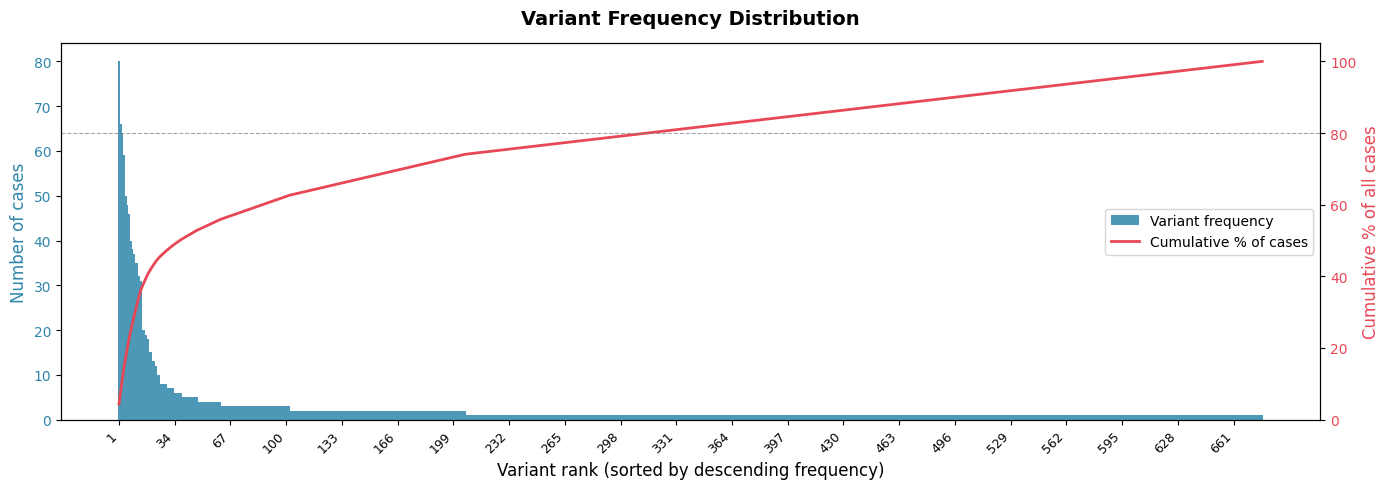

Top-1  variant covers : 4.4% of all cases
Top-5  variants cover : 17.5% of all cases
Top-10 variants cover : 29.0% of all cases
80% of cases covered by top-314 variant(s)
Remaining 364 variants cover the last 20% of cases


In [66]:
# Build sorted frequency series
variant_freq = pd.Series(
    {v: len(cases) if not isinstance(cases, int) else cases
     for v, cases in variants_dict.items()},
    name='frequency'
).sort_values(ascending=False)

ranks = list(range(1, len(variant_freq) + 1))
freqs = variant_freq.values
cum_pct = np.cumsum(freqs) / freqs.sum() * 100   # cumulative percentage

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart of frequencies
ax1.bar(ranks, freqs, color='#2E86AB', alpha=0.85, width=1.0, label='Variant frequency')
ax1.set_xlabel('Variant rank (sorted by descending frequency)', fontsize=12)
ax1.set_ylabel('Number of cases', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Show x-ticks sparsely so labels do not overlap
tick_step = max(1, len(ranks) // 20)
ax1.set_xticks(ranks[::tick_step])
ax1.set_xticklabels(ranks[::tick_step], rotation=45, ha='right', fontsize=9)

# Cumulative line on secondary axis
ax2 = ax1.twinx()
ax2.plot(ranks, cum_pct, color='#E84855', linewidth=2, label='Cumulative % of cases')
ax2.axhline(80, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_ylabel('Cumulative % of all cases', fontsize=12, color='#E84855')
ax2.tick_params(axis='y', labelcolor='#E84855')
ax2.set_ylim(0, 105)

plt.title('Variant Frequency Distribution', fontsize=14, fontweight='bold', pad=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

# Supporting numbers
top1 = freqs[0] / freqs.sum() * 100
top5 = freqs[:5].sum() / freqs.sum() * 100
top10 = freqs[:10].sum() / freqs.sum() * 100
idx80 = int(np.searchsorted(cum_pct, 80))

print(f'Top-1  variant covers : {top1:.1f}% of all cases')
print(f'Top-5  variants cover : {top5:.1f}% of all cases')
print(f'Top-10 variants cover : {top10:.1f}% of all cases')
print(f'80% of cases covered by top-{idx80+1} variant(s)')
print(f'Remaining {len(ranks)-(idx80+1)} variants cover the last 20% of cases')

The distribution is highly right-skewed: a small number of variants account for the majority of cases, while most variants appear only ones or twice. This indicates that the process has a few dominant paths, but also a long tail of exceptions caused by re-submissions, document corrections, or manual overrides. The fact that 80% of cases are covered only after hundreds of variants suggests process complexity and fragmentation from the main flows.

### <b>1e.</b> Examine the distribution of case durations. 

Report the minimum, maximum, mean, median, and standard deviation of case duration.
What insights can you derive about the process? (approx. 3–4 sentences)

In [67]:
# Compute case durations
duration_df = (
    all_log
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
    .rename(columns={'min': 'start', 'max': 'end'})
)
duration_df['start'] = pd.to_datetime(duration_df['start'], utc=True)
duration_df['end']   = pd.to_datetime(duration_df['end'],   utc=True)

# Transform the values into hours and days
duration_df['duration_hours'] = (
    (duration_df['end'] - duration_df['start']).dt.total_seconds() / 3600
)
duration_df['duration_days'] = duration_df['duration_hours'] / 24

dur_h = duration_df['duration_hours']
dur_d = duration_df['duration_days']

# Descriptive statistics
stats = {
    'Minimum'         : (dur_h.min(),         dur_d.min()),
    'Maximum'         : (dur_h.max(),         dur_d.max()),
    'Mean'            : (dur_h.mean(),        dur_d.mean()),
    'Median'          : (dur_h.median(),      dur_d.median()),
    'Std deviation'   : (dur_h.std(),         dur_d.std()),
    '25th percentile' : (dur_h.quantile(0.25), dur_d.quantile(0.25)),
    '75th percentile' : (dur_h.quantile(0.75), dur_d.quantile(0.75)),
}

print('=' * 55)
print('  CASE DURATION STATISTICS')
print('=' * 55)
print(f'  {"Metric":<22}  {"Hours":>10}  {"Days":>10}')
print('-' * 55)
for label, (h, d) in stats.items():
    print(f'  {label:<22}  {h:>10.2f}  {d:>10.2f}')
print('=' * 55)

  CASE DURATION STATISTICS
  Metric                       Hours        Days
-------------------------------------------------------
  Minimum                       6.10        0.25
  Maximum                   18202.47      758.44
  Mean                       7009.24      292.05
  Median                     5300.63      220.86
  Std deviation              5298.31      220.76
  25th percentile            4530.46      188.77
  75th percentile            9577.69      399.07


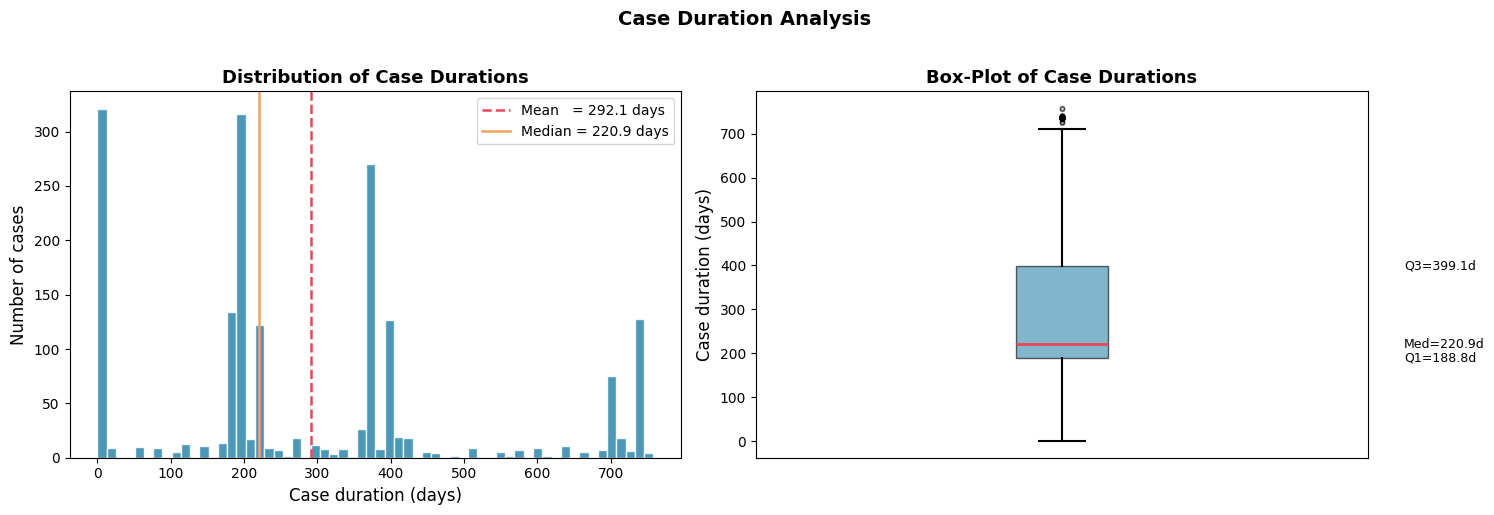

Cases with duration less than 1 day : 161
Cases longer than 30 days           : 1,490
Cases longer than 365 days          : 745
Mean/Median gap (days)              : 71.19


In [68]:
# Plot: Histogram + Box-plot 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram 
ax = axes[0]
ax.hist(dur_d, bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.axvline(dur_d.mean(),   color='#E84855', linestyle='--', linewidth=1.8,
           label=f'Mean   = {dur_d.mean():.1f} days')
ax.axvline(dur_d.median(), color='#F4A261', linestyle='-',  linewidth=1.8,
           label=f'Median = {dur_d.median():.1f} days')
ax.set_xlabel('Case duration (days)', fontsize=12)
ax.set_ylabel('Number of cases',      fontsize=12)
ax.set_title('Distribution of Case Durations', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Right: box-plot 
ax2 = axes[1]
ax2.boxplot(
    dur_d, vert=True, patch_artist=True,
    boxprops=dict(facecolor='#2E86AB', alpha=0.6),
    medianprops=dict(color='#E84855', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.3, color='grey')
)
ax2.set_ylabel('Case duration (days)', fontsize=12)
ax2.set_title('Box-Plot of Case Durations',
              fontsize=13, fontweight='bold')
ax2.set_xticks([])

# Annotate quartiles
q1, med, q3 = dur_d.quantile(0.25), dur_d.median(), dur_d.quantile(0.75)
for val, lbl in [(q1, f'Q1={q1:.1f}d'), (med, f'Med={med:.1f}d'), (q3, f'Q3={q3:.1f}d')]:
    ax2.annotate(lbl, xy=(1.06, val), xycoords=('axes fraction', 'data'),
                 fontsize=9, va='center')

plt.suptitle('Case Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Additional detail
zero_dur = (dur_d <= 1).sum()
over30d  = (dur_d > 30).sum()
over365d  = (dur_d > 365).sum()
print(f'Cases with duration less than 1 day : {zero_dur:,}')
print(f'Cases longer than 30 days           : {over30d:,}')
print(f'Cases longer than 365 days          : {over365d:,}')
print(f'Mean/Median gap (days)              : {dur_d.mean() - dur_d.median():.2f}')

The distribution is strongly right-skewed, with the mean much higher than the median, indicating the presence of very long cases pulling the average upward. Cases with duration near zero suggest automated fast-track rejections. While most cases take around ~180-230 days, a significant number extend far beyond that number, probably pointing to exceptional cases. 


Overall, the wide range and large standard deviation suggest high variability and inconsistent processing times. 

## <b>Question 2</b>: General Visual Analytics & Exploration
To deepen the understanding of the event data, we apply techniques from visual analytics. 

### <b>2a.</b> Variant Analysis
Using a variant exploration, select five variants and
report their frequencies. Include a visualization of one variant and annotate it to
highlight repetitive or similar patterns. Compare the five variants with respect to:
- contained activities
- length
- attributes
Provide a concise description. 

In [69]:
# Sort all variants by descending frequency
sorted_variants = sorted(
    variants_dict.items(),
    key=lambda x: len(x[1]) if isinstance(x[1], (list, tuple)) else x[1],
    reverse=True
)

# Select five variants
# Indices chosen to get the top-3, a mid-range, and a rare variant.
total_cases = all_log['case:concept:name'].nunique()
mid_idx = len(sorted_variants) // 2
rare_idx = len(sorted_variants) - 1

selected_indices = [0, 1, 2, mid_idx, rare_idx]
selected_variants = [sorted_variants[i] for i in selected_indices]

# Print the summary table
print(f'{'Rank':<6} {'Frequency':>10} {'% of cases':>13} {'Length':>8}   Variant label')
print('-' * 100)
for rank, (variant, cases) in zip(selected_indices, selected_variants):
    freq = cases if isinstance(cases, int) else len(cases)
    pct = freq / total_cases * 100
    length = len(variant)
    label = f'V{rank+1}: {" → ".join(variant[:3])}{'...' if length > 3 else ''}'
    print(f'{rank+1:<6} {freq:>10,} {pct:>10.2f}%  {length:>7}     {label}')

Rank    Frequency    % of cases   Length   Variant label
----------------------------------------------------------------------------------------------------
1              80       4.40%       23     V1: Application Registered → Retrieve Identity Document → Retrieve Internal Log Data...
2              66       3.63%       23     V2: Application Registered → Retrieve Identity Document → Retrieve Internal Log Data...
3              64       3.52%       23     V3: Application Registered → Retrieve Identity Document → Verify ID Automatically...
340             1       0.05%       41     V340: Application Registered → Retrieve Identity Document → Verify ID Automatically...
678             1       0.05%       33     V678: Application Registered → Retrieve Identity Document → Verify ID Automatically...


In [70]:
# Build a comparison DataFrame for each selected variant
rows = []
for rank, (variant, cases) in zip(selected_indices, selected_variants):
    activities = list(variant)
    present_attrs = [a for a in all_log.loc[rank].dropna().index.tolist() if a in event_cols]

    rows.append({
        'Variant'    : rank+1,
        'Frequency'  : cases,
        'Length'     : len(variant),
        'First act'  : activities[0],
        'Last act'   : activities[-1],
        'Unique acts': len(set(activities)),
        'Repeated acts': 'Yes' if len(set(activities)) < len(activities) else 'No',
        'Attributes present': ', '.join(present_attrs) if present_attrs else '(none extra)',
    })

cmp_df = pd.DataFrame(rows)
cmp_df.head(5)

,Variant,Frequency,Length,First act,Last act,Unique acts,Repeated acts,Attributes present
0,1,80,23,Application Registered,Repayment Completed,18,Yes,org:resource
1,2,66,23,Application Registered,Repayment Completed,18,Yes,org:resource
2,3,64,23,Application Registered,Repayment Completed,18,Yes,"org:resource, prior_defaults, prior_applications"
3,340,1,41,Application Registered,Repayment Completed,19,Yes,org:resource
4,678,1,33,Application Registered,Send to Collections,21,Yes,"org:resource, code"


In [71]:
print('Attributes present in the variants:', end='\n\n')
for i in range(5):
    print(f"Variant {i+1}: {cmp_df['Attributes present'].iloc[i]}")

Attributes present in the variants:

Variant 1: org:resource
Variant 2: org:resource
Variant 3: org:resource, prior_defaults, prior_applications
Variant 4: org:resource
Variant 5: org:resource, code


In [72]:
# Create a function to plot a variant as a horizontal sequence
def plot_variant(variant_tuple, title, figwidth=18):
    """
    Draw each activity in the variant as a coloured box connected by arrows.
    Repeated activities are highlighted in a different colour.
    Parameters
    ----------
    variant_tuple : tuple of str   – ordered activity sequence
    title         : str            – plot title
    figwidth      : float          – figure width in inches
    """

    acts = list(variant_tuple)
    n = len(acts)

    # Identify repeated activities
    counts = Counter(acts)
    repeated = {a for a, c in counts.items() if c > 1}

    # Layout constants
    BOX_W  = 2.6   # width of each activity box
    BOX_H  = 0.7   # height
    GAP    = 0.5   # horizontal gap between boxes
    STEP   = BOX_W + GAP
    FIG_H  = 2.2

    # Colours
    CLR_NORMAL   = '#2E86AB'   # standard activity
    CLR_REPEAT   = '#E84855'   # repeated activity
    CLR_TEXT     = 'white'

    fig, ax = plt.subplots(figsize=(figwidth, FIG_H))
    ax.set_xlim(-0.3, n * STEP + 0.3)
    ax.set_ylim(-0.6, 1.2)
    ax.axis('off')

    # Draw boxes and arrows
    for i, act in enumerate(acts):
        x     = i * STEP
        color = CLR_REPEAT if act in repeated else CLR_NORMAL

        # Box for the activity
        box = mpatches.FancyBboxPatch(
            (x, 0), BOX_W, BOX_H,
            boxstyle='round,pad=0.1',
            facecolor=color, edgecolor='white', linewidth=1.5
        )
        ax.add_patch(box)

        # Wrap activity names across multiple lines
        words = act.split()
        label = '\n'.join(words)
        ax.text(x + BOX_W / 2, BOX_H / 2, label,
                ha='center', va='center', color=CLR_TEXT,
                fontsize=6, fontweight='bold', wrap=True)

        # Step number below the box
        ax.text(x + BOX_W / 2, -0.15, str(i + 1),
                ha='center', va='top', fontsize=8, color='grey', fontweight='bold')

        # Arrow to next box
        if i < n - 1:
            ax.annotate(
                '', xy=(x + BOX_W + GAP, BOX_H / 2),
                xytext=(x + BOX_W, BOX_H / 2),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5)
            )

    # Add the legend
    if repeated:
        legend_handles = [
            mpatches.Patch(facecolor=CLR_NORMAL, label='Standard activity'),
            mpatches.Patch(facecolor=CLR_REPEAT, label='Repeated activity (loop / re-check)'),
        ]
        ax.legend(handles=legend_handles, loc='upper right',
                  fontsize=8, framealpha=0.9, bbox_to_anchor=(1, 1.15))

    plt.title(title, fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

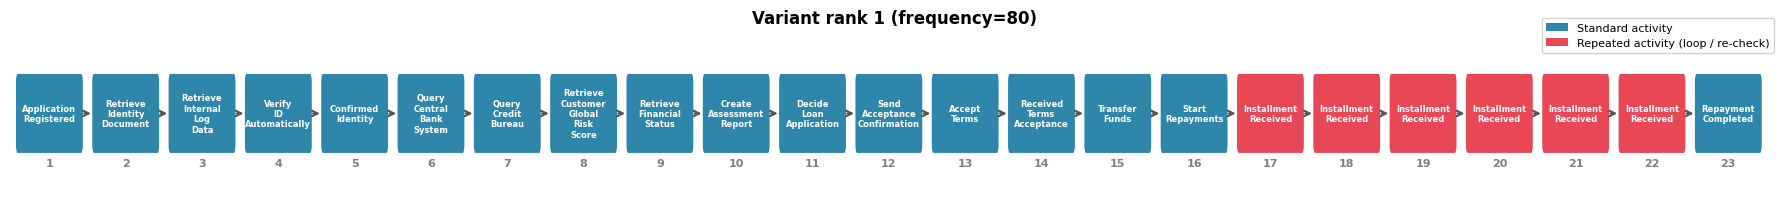

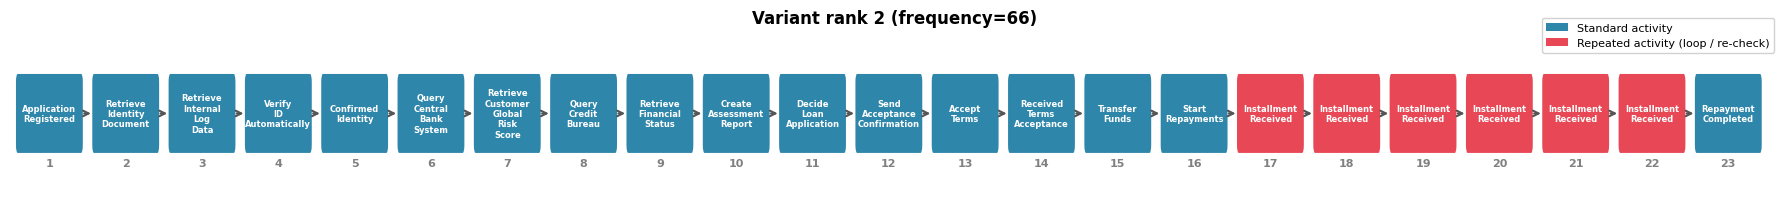

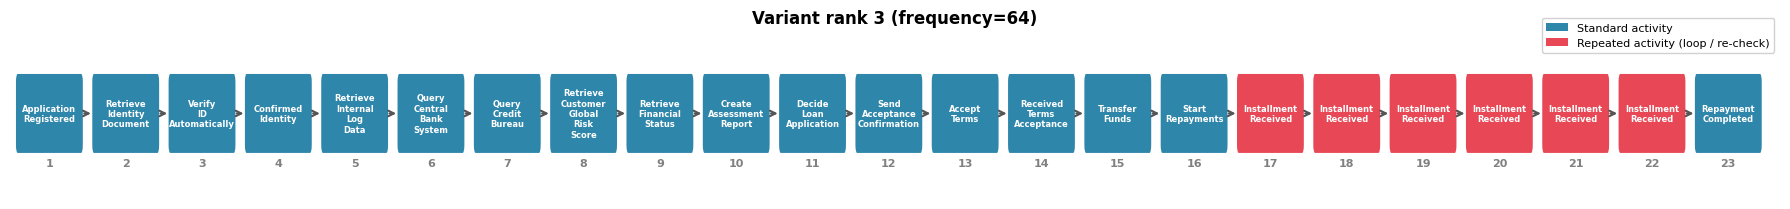

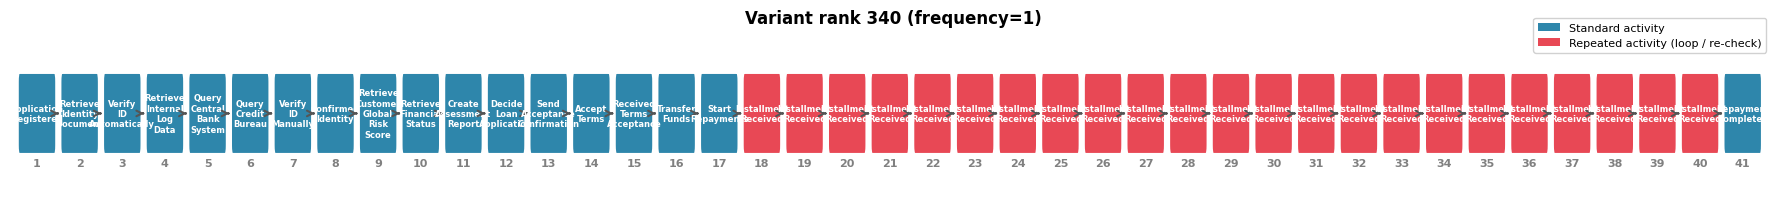

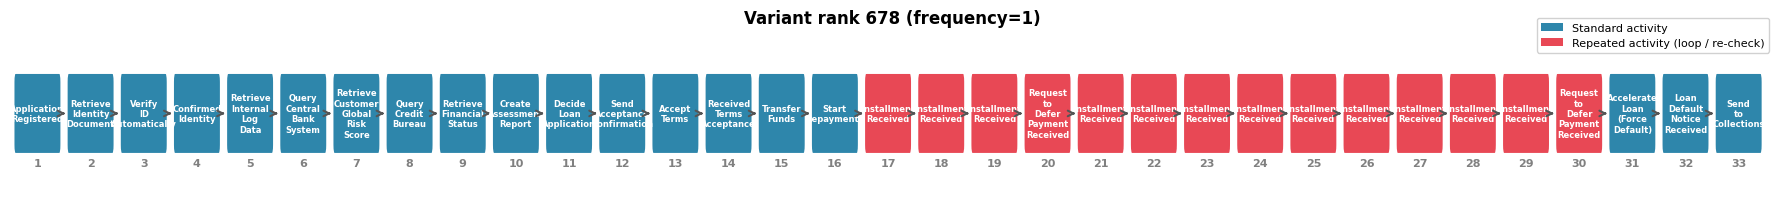

In [73]:
# Plot the variants
for i in selected_indices:
    v1_tuple, v1_cases = sorted_variants[i]
    plot_variant(
        v1_tuple,
        title=f'Variant rank {i+1} (frequency={v1_cases:,})'
    )

The top three variants (frequencies 80, 66, 64) contain largely the same core activities (application registration, identity verification, credit checks, loan decision, etc.) with only differences in ordering. This indicates a standardized “happy path” with repeated Installment Received loops at the end.

Variants 4 and 5 (frequency = 1) are much longer (up to ~40+ steps) and include many more repeated activities and exceptions (defer payment requests or collections), reflecting untypical or problematic cases. 

In terms of attributes, all variants include org:resource and lifecycle:transition, but additional attributes (like prior_defaults or prior_applications) appear in less frequent variants, suggesting these are linked to more complex or exceptional cases. 

Overall, high-frequency variants are shorter and standardized, whereas low-frequency ones are longer, more repetitive, and attribute-rich, indicating higher process complexity.

### <b>2b.</b>  DFG
Construct a frequency-annotated Directly-Follows Graph (DFG) using the event log.
Briefly describe the graph and discuss the insights gained. 

In [74]:
# Discover the frequency DFG
dfg, start_acts, end_acts = pm4py.discover_directly_follows_graph(all_log)

print(f'Number of DFG edges : {len(dfg):,}')
print(f'Start activities : {list(start_acts.keys())}')
print(f'End activities : {list(end_acts.keys())}')

# Top-20 most frequent edges
top_edges = sorted(dfg.items(), key=lambda x: x[1], reverse=True)[:20]
print('\nTop-20 most frequent directly-follows pairs:')
print(f'  {"From activity":<45} {"To activity":<45} {"Frequency":>10}')
print('-' * 105)
for (src, tgt), freq in top_edges:
    print(f'  {src:<45} {tgt:<45} {freq:>10,}')

Number of DFG edges : 81
Start activities : ['Application Registered']
End activities : ['Send Rejection Notification', 'Send to Collections', 'Repayment Completed']

Top-20 most frequent directly-follows pairs:
  From activity                                 To activity                                    Frequency
---------------------------------------------------------------------------------------------------------
  Installment Received                          Installment Received                              13,990
  Application Registered                        Retrieve Identity Document                         1,820
  Create Assessment Report                      Decide Loan Application                            1,671
  Accept Terms                                  Received Terms Acceptance                          1,499
  Decide Loan Application                       Send Acceptance Confirmation                       1,499
  Received Terms Acceptance                     Tran

In [75]:
# Build the visualisation for the frequency-annotated DFG
gviz = dfg_visualizer.apply(
    dfg,
    log=all_log,
    variant=dfg_visualizer.Variants.FREQUENCY,      # darker = more frequent
    parameters={
        'start_activities': start_acts,
        'end_activities' : end_acts,
        'format' : 'png',
        'size' : (6, 4)
    }
)

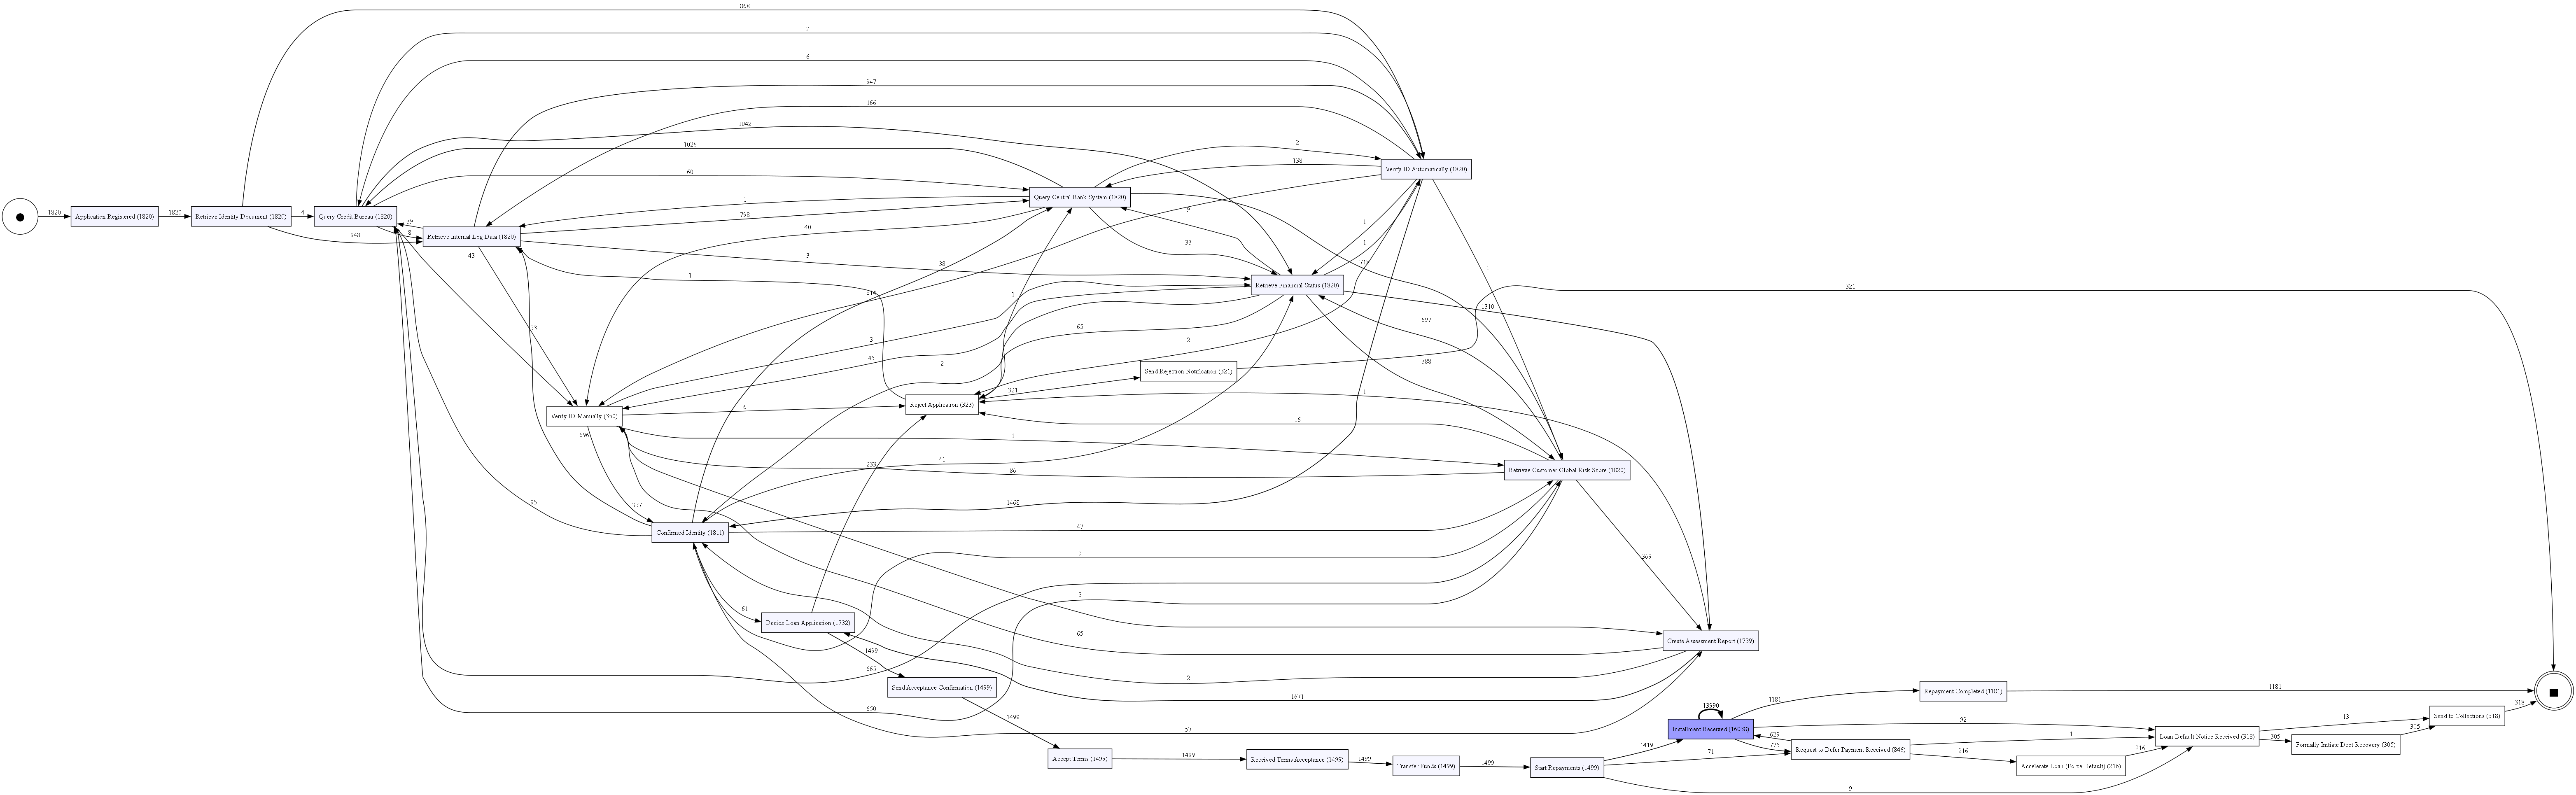

In [76]:
# Idk how is better to display, smaller to fit the notebook
Image(gviz.render(), width=1800)

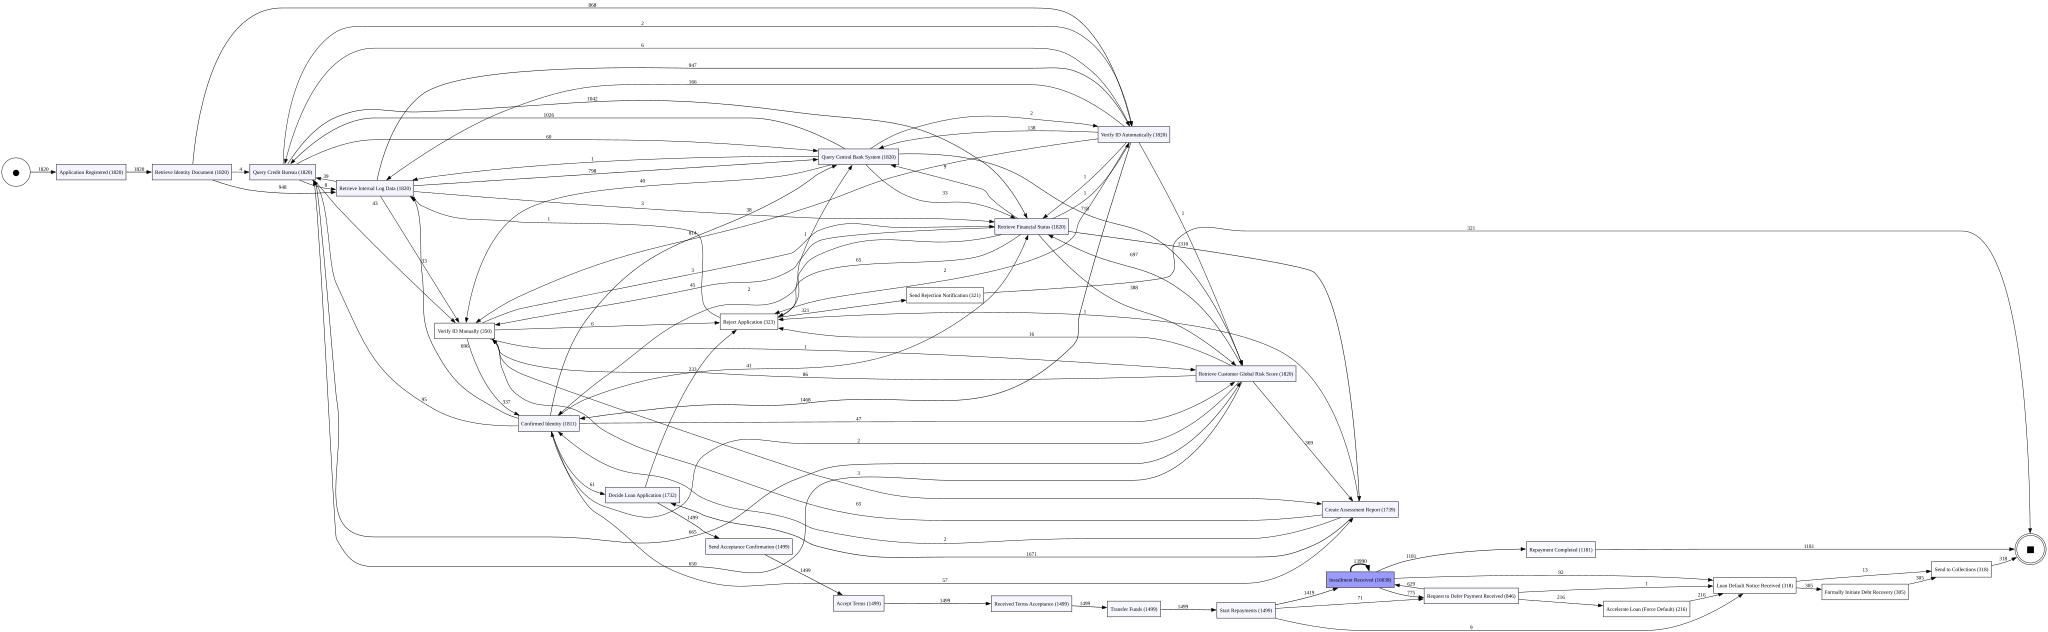

In [77]:
# Or detatiled, but scrollable
display(gviz)

In [78]:
# Compute in-degree and out-degree for each node 
out_degree = defaultdict(int)
in_degree = defaultdict(int)
out_freq = defaultdict(int)   # total outgoing frequency
in_freq = defaultdict(int)    # total incoming frequency

for (src, tgt), freq in dfg.items():
    out_degree[src] += 1
    in_degree[tgt] += 1
    out_freq[src] += freq
    in_freq[tgt] += freq

all_activities = sorted(set(list(out_degree) + list(in_degree)))

# Quantitative DFG summary
summary_df = pd.DataFrame({
    'Activity'     : all_activities,
    'Out-degree'   : [out_degree[a] for a in all_activities],
    'In-degree'    : [in_degree[a] for a in all_activities],
    'Out-frequency': [out_freq[a] for a in all_activities],
    'In-frequency' : [in_freq[a] for a in all_activities],
    'Is start'     : [a in start_acts for a in all_activities],
    'Is end'       : [a in end_acts for a in all_activities],
}).sort_values('Out-frequency', ascending=False)

print('Activity-level DFG statistics (sorted by outgoing frequency):')
summary_df

Activity-level DFG statistics (sorted by outgoing frequency):


,Activity,Out-degree,In-degree,Out-frequency,In-frequency,Is start,Is end
7,Installment Received,4,3,16038,16038,False,False
2,Application Registered,1,0,1820,0,True,False
9,Query Central Bank System,6,6,1820,1820,False,False
16,Retrieve Financial Status,7,7,1820,1820,False,False
18,Retrieve Internal Log Data,5,6,1820,1820,False,False
24,Verify ID Automatically,8,5,1820,1820,False,False
15,Retrieve Customer Global Risk Score,6,6,1820,1820,False,False
10,Query Credit Bureau,6,6,1820,1820,False,False
17,Retrieve Identity Document,3,1,1820,1820,False,False
3,Confirmed Identity,7,5,1811,1811,False,False


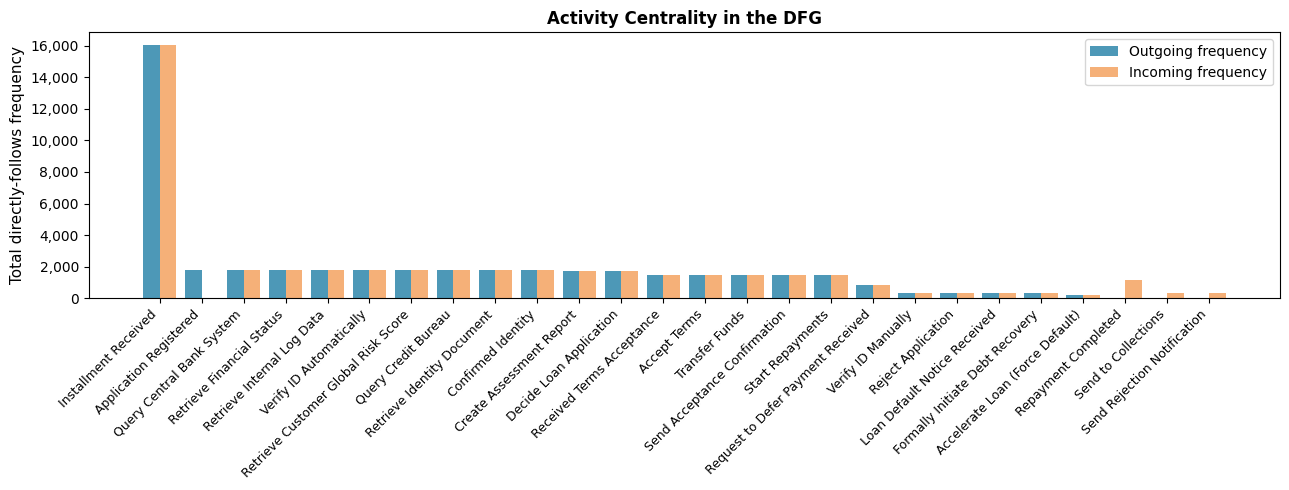

In [79]:
# Plot activity in/out frequency
fig, ax = plt.subplots(figsize=(13, 5))

acts_sorted = summary_df['Activity'].tolist()
out_f_sorted = summary_df['Out-frequency'].tolist()
in_f_sorted = summary_df['In-frequency'].tolist()

x = np.arange(len(acts_sorted))
w = 0.4

ax.bar(x - w/2, out_f_sorted, width=w, color='#2E86AB', alpha=0.85, label='Outgoing frequency')
ax.bar(x + w/2, in_f_sorted,  width=w, color='#F4A261', alpha=0.85, label='Incoming frequency')

ax.set_xticks(x)
ax.set_xticklabels(acts_sorted, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Total directly-follows frequency', fontsize=11)
ax.set_title('Activity Centrality in the DFG', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

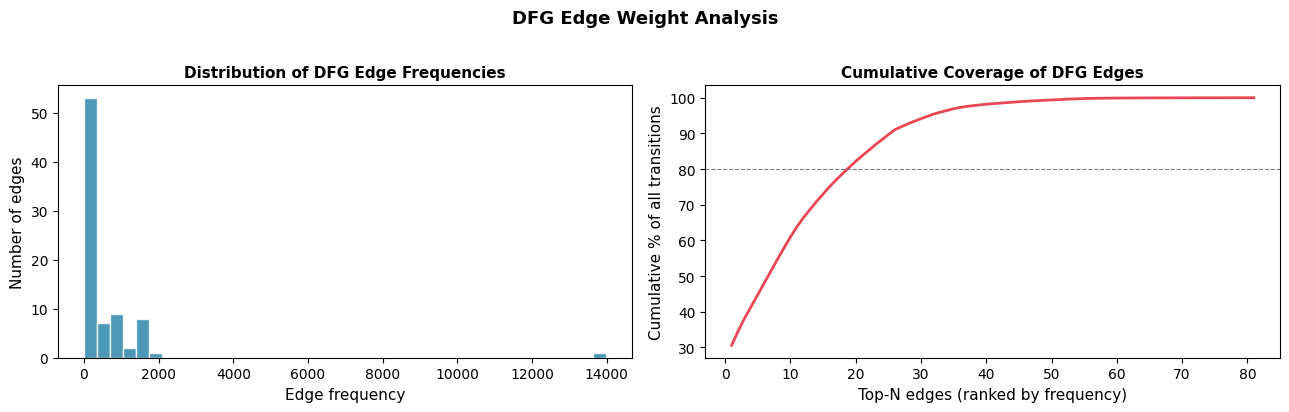

Total unique DFG edges            : 81
Total transition occurrences      : 45,733
Edges covering 80% of transitions : 19
Min edge frequency                : 1
Median edge frequency             : 71.0
Max edge frequency                : 13,990


In [80]:
# Edge weight distribution
edge_freqs = sorted(dfg.values(), reverse=True)
total_edge_weight = sum(edge_freqs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of edge frequencies
axes[0].hist(edge_freqs, bins=40, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Edge frequency', fontsize=11)
axes[0].set_ylabel('Number of edges', fontsize=11)
axes[0].set_title('Distribution of DFG Edge Frequencies', fontsize=11, fontweight='bold')

# Right: percentage by top-N edges
cum = np.cumsum(edge_freqs) / total_edge_weight * 100
axes[1].plot(range(1, len(cum)+1), cum, color='#E84855', linewidth=2)
axes[1].axhline(80, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Top-N edges (ranked by frequency)', fontsize=11)
axes[1].set_ylabel('Cumulative % of all transitions', fontsize=11)
axes[1].set_title('Cumulative Coverage of DFG Edges', fontsize=11, fontweight='bold')

# Add 80% line
idx80 = int(np.searchsorted(cum, 80))

plt.suptitle('DFG Edge Weight Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print supporting numbers
print(f'Total unique DFG edges            : {len(edge_freqs):,}')
print(f'Total transition occurrences      : {total_edge_weight:,}')
print(f'Edges covering 80% of transitions : {idx80+1}')
print(f'Min edge frequency                : {edge_freqs[-1]:,}')
print(f'Median edge frequency             : {np.median(edge_freqs):.1f}')
print(f'Max edge frequency                : {edge_freqs[0]:,}')

The directly-follows graph (DFG) shows a structured core application registration process flow through verification, credit checks, approval, and payment initiation, surrounded by some alternative paths and loops. A small number of transitions dominate the flow (max frequency ≈13,990), with just 19 edges covering 80% of all 45,000 transitions, confirming a strong “backbone” of standard behavior.

At the same time, the edge frequency distribution is highly skewed (median = 71, min = 1), showing many rare transitions that reflect exceptions, reworks, or deviations. Centrality analysis highlights activities like Installment Received as major hubs, largely due to repeated loops, which aligns with earlier findings on long-tail variants and repetition in later stages. Overall, the graph reinforces that while the process has a clear main path, it is heavily influenced by variability and iterative behaviors.

## <b>Question 3</b>: Use Case-Specific Visual Analytics & Exploration

## <b>Question 4</b>: Process Discovery
After these exploratory perspectives on the process, we want to take a deeper look at the
control flow of the process. As the perfect model or discovery algorithm does not exist, it
makes sense to apply multiple algorithms to different perspectives on the process and
compare their results. Some algorithms handle noise better than others. Some algorithms
have stronger or weaker modeling bias, making it a mix-and-match problem.

### <b>4a.</b> Discover Petri Nets
Before focusing on different perspectives on the processes and creating separate
views, we will try to discover a holistic model of the entire process using out-of-thebox process discovery algorithms.

In [81]:
# Store all models in a list for easy iteration in later sub-questions
models = []

# 1. INDUCTIVE MINER – (noise_threshold = 0.0)
print('1. Inductive Miner (noise=0.0)')
im_net, im_im, im_fm = pm4py.discover_petri_net_inductive(rejected_loans, noise_threshold=0.0)
print(f'   places={len(im_net.places)}  transitions={len(im_net.transitions)}  '
      f'arcs={len(im_net.arcs)}', end='\n\n')
models.append(('IM', im_net, im_im, im_fm, 'Inductive Miner (noise=0.0)'))


# 2. INDUCTIVE MINER INFREQUENT – threshold 0.5
print('2. Inductive Miner infrequent (noise=0.5)')
imf05_net, imf05_im, imf05_fm = pm4py.discover_petri_net_inductive(rejected_loans, noise_threshold=0.5)
print(f'   places={len(imf05_net.places)}  transitions={len(imf05_net.transitions)}  '
      f'arcs={len(imf05_net.arcs)}', end='\n\n')
models.append(('IMf05', imf05_net, imf05_im, imf05_fm, 'IM infrequent (noise=0.5)'))


# 3. INDUCTIVE MINER INFREQUENT – threshold 0.8
print('3. Inductive Miner infrequent (noise=0.8)')
imf08_net, imf08_im, imf08_fm = pm4py.discover_petri_net_inductive(rejected_loans, noise_threshold=0.8)
print(f'   places={len(imf08_net.places)}  transitions={len(imf08_net.transitions)}  '
      f'arcs={len(imf08_net.arcs)}', end='\n\n')
models.append(('IMf08', imf08_net, imf08_im, imf08_fm, 'IM infrequent (noise=0.8)'))


# 4. ILP MINER
print('4. ILP Miner')
ilp_net, ilp_im, ilp_fm = pm4py.discover_petri_net_ilp(rejected_loans)
print(f'   places={len(ilp_net.places)}  transitions={len(ilp_net.transitions)}  '
      f'arcs={len(ilp_net.arcs)}', end='\n\n')
models.append(('ILP', ilp_net, ilp_im, ilp_fm, 'ILP Miner'))


# 5. HEURISTICS MINER
print('5. Heuristics Miner')
heu_net, heu_im, heu_fm = pm4py.discover_petri_net_heuristics(rejected_loans)
print(f'   places={len(heu_net.places)}  transitions={len(heu_net.transitions)}  '
      f'arcs={len(heu_net.arcs)}', end='\n\n')
models.append(('Heu', heu_net, heu_im, heu_fm, 'Heuristics Miner'))

1. Inductive Miner (noise=0.0)
   places=27  transitions=26  arcs=66

2. Inductive Miner infrequent (noise=0.5)
   places=16  transitions=14  arcs=32

3. Inductive Miner infrequent (noise=0.8)
   places=17  transitions=17  arcs=36

4. ILP Miner


discovering Petri net using ILP miner, completed causal relations :: 100%|██████████| 36/36 [00:00<00:00, 152.05it/s]


   places=23  transitions=15  arcs=105

5. Heuristics Miner
   places=31  transitions=36  arcs=90




--- Inductive Miner (noise=0.0) ---
    Places: 27  |  Transitions: 26  |  Arcs: 66


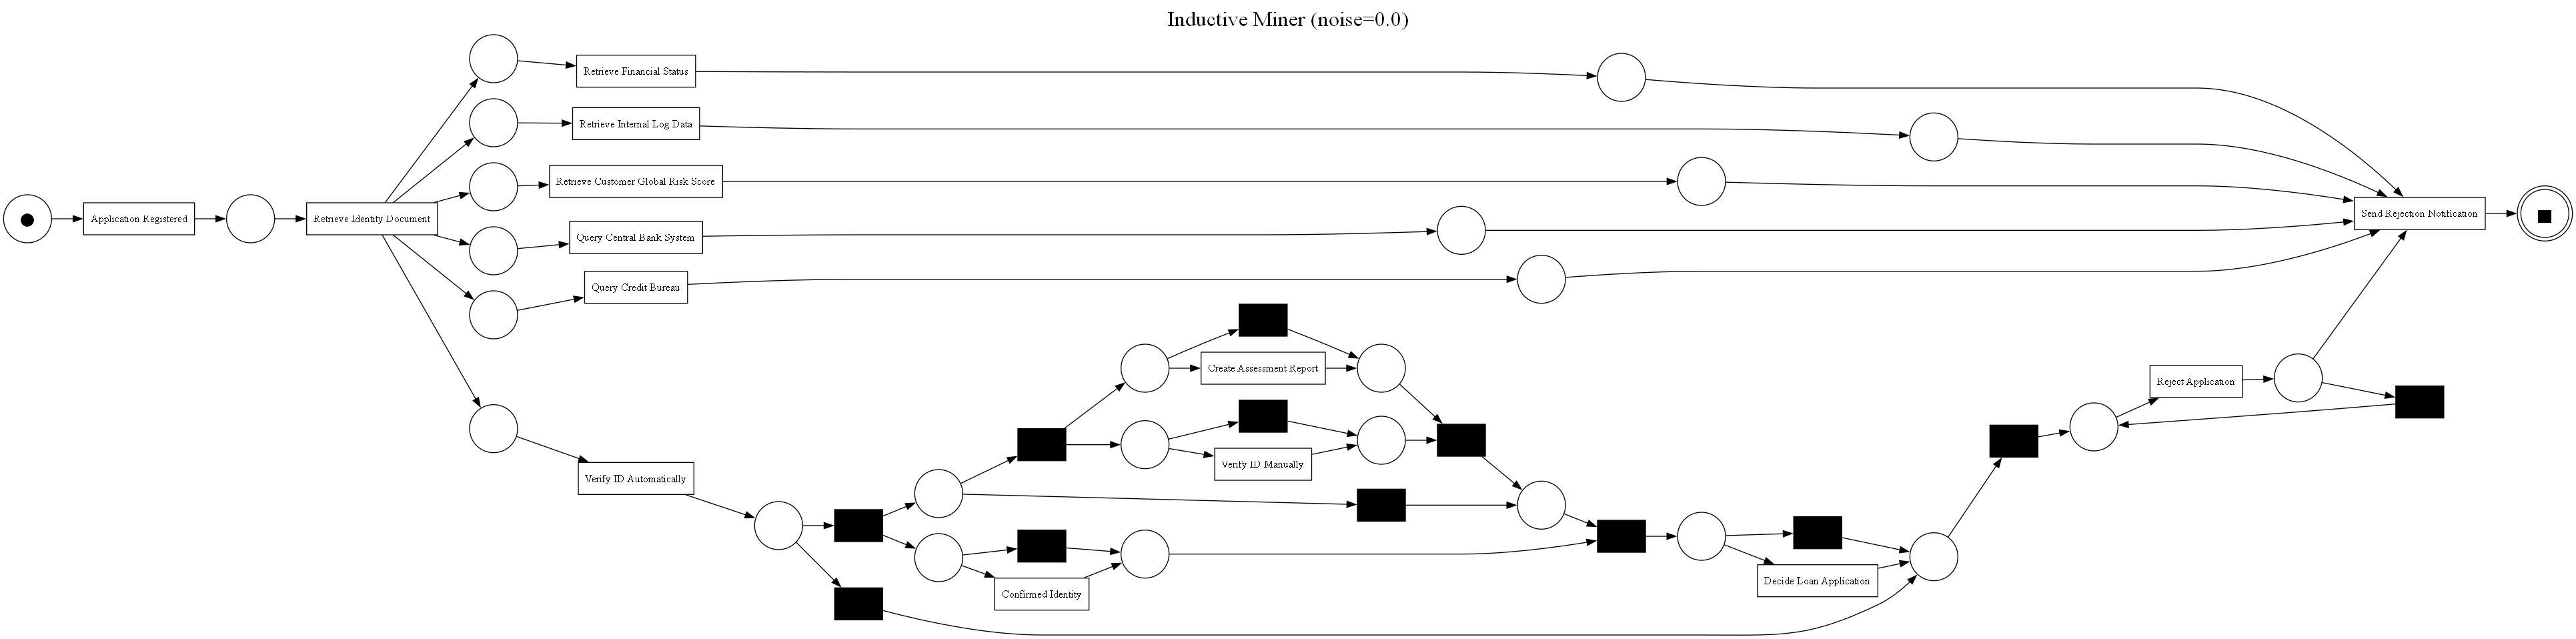


--- IM infrequent (noise=0.5) ---
    Places: 16  |  Transitions: 14  |  Arcs: 32


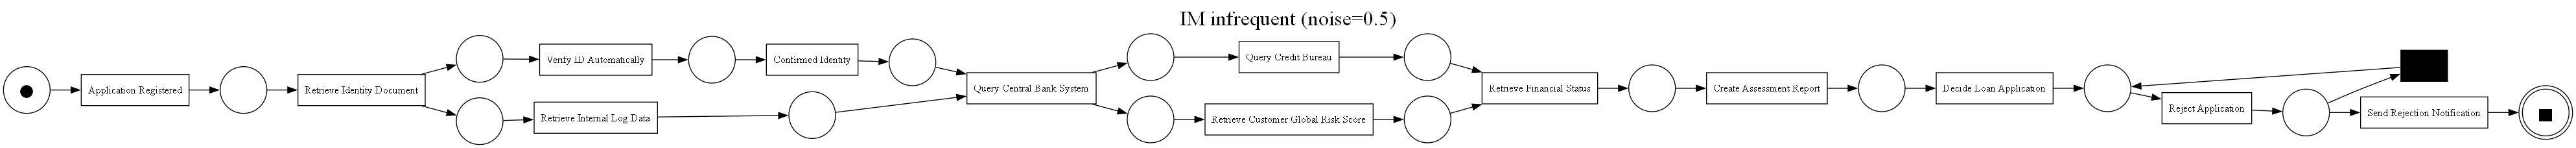


--- IM infrequent (noise=0.8) ---
    Places: 17  |  Transitions: 17  |  Arcs: 36


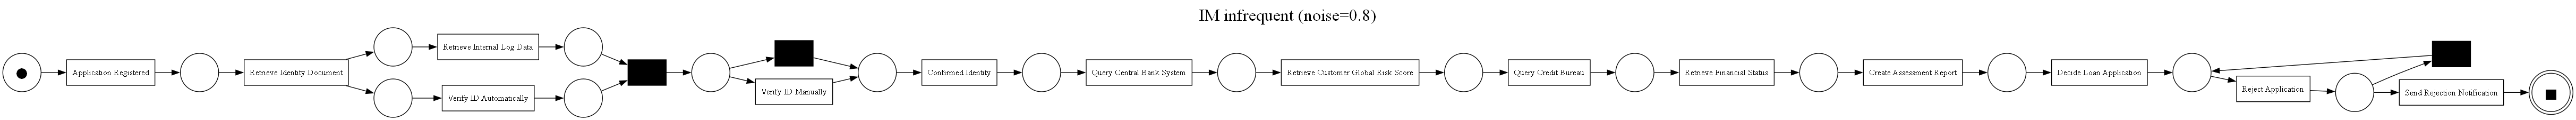


--- ILP Miner ---
    Places: 23  |  Transitions: 15  |  Arcs: 105


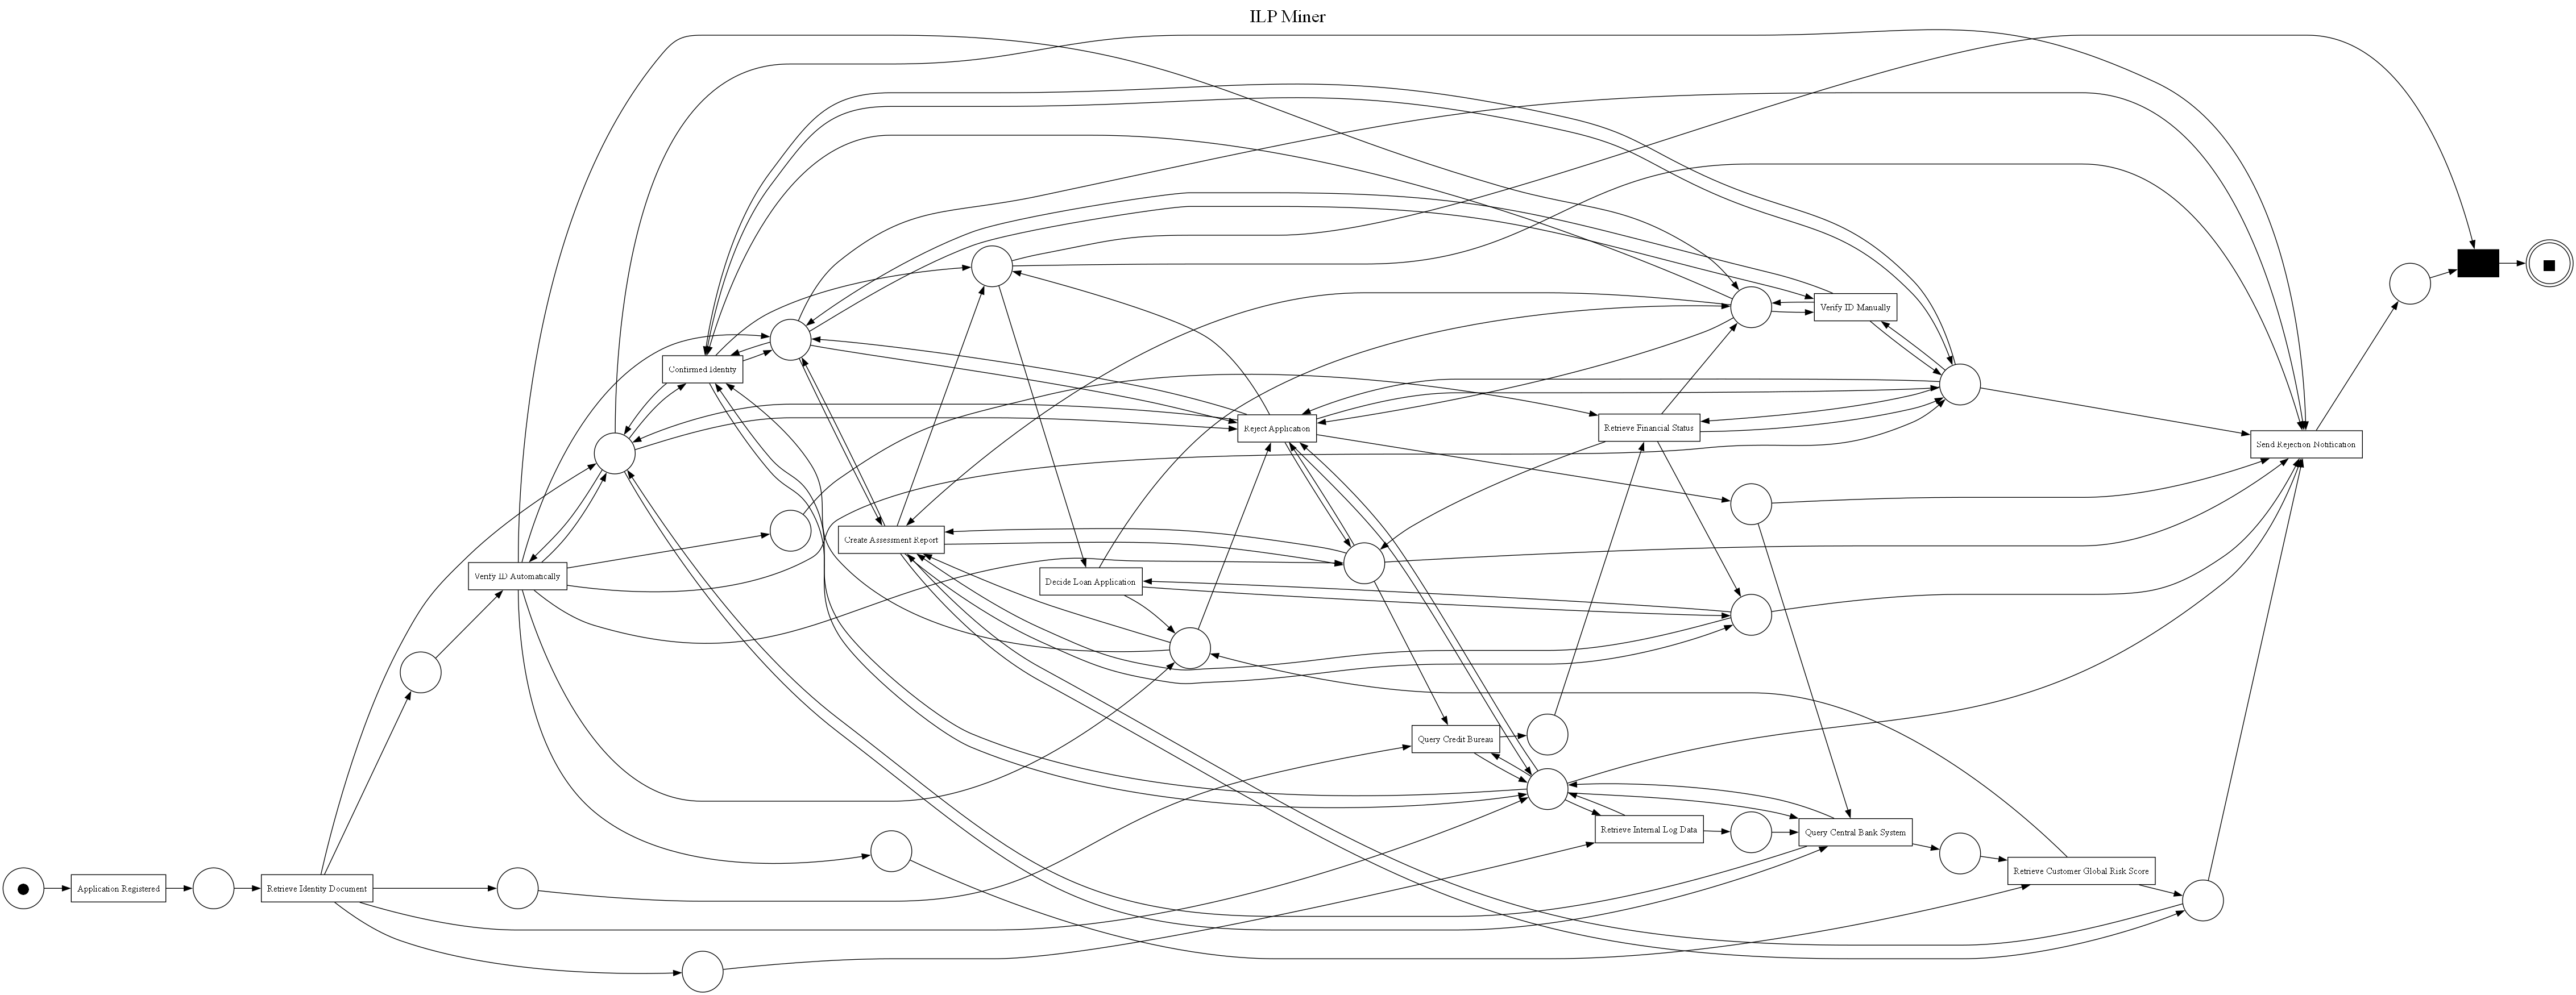


--- Heuristics Miner ---
    Places: 31  |  Transitions: 36  |  Arcs: 90


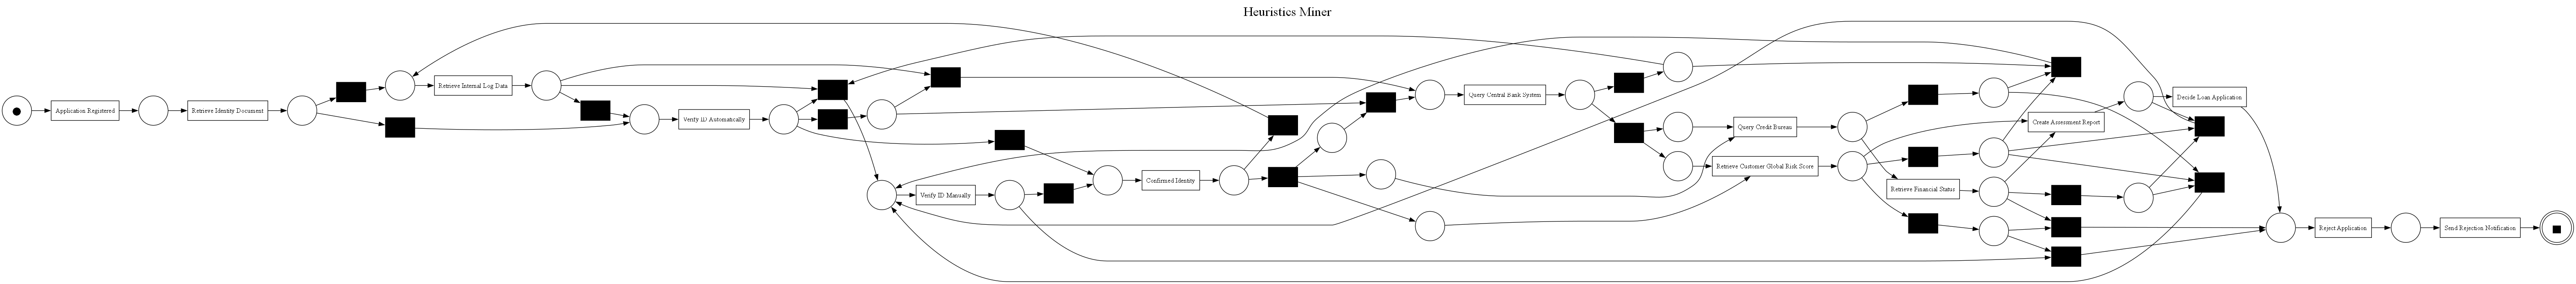

In [82]:
# Render and display all five Petri nets
for key, net, im, fm, title in models:
    path = f'images/model_{key}.png'
    pm4py.save_vis_petri_net(net, im, fm, path, rankdir='LR', graph_title=title)
    print(f'\n--- {title} ---')
    print(f'    Places: {len(net.places)}  |  Transitions: {len(net.transitions)}  |  Arcs: {len(net.arcs)}')
    display(Image(filename=path))

### <b>4b.</b> Soundness, Fitness and Precision
For an initial evaluation of the discovered models, calculate their alignmentbased fitness and precision, if possible (otherwise explain why it is not possible), using
fitness_alignments and precision_alignments. Also, check their soundness with
check_soundness.

A Petri net is a SOUND Workflow Net if:
  1. It has exactly one source place (has tokens only in initial marking)
  2. It has exactly one sink place (receives tokens in final marking)
  3. Every node is on some path from source to sink
  4. No deadlocks: from any reachable marking, the final marking is reachable
  5. No improper completion: at the final marking, no extra tokens exist elsewhere
  6. No dead transitions: every transition can fire in some execution

#### Custom functions to work with timeout

In [83]:
# Function to forcefully kill a process on Windows
def _force_kill_windows(pid):
    PROCESS_TERMINATE = 0x0001
    handle = ctypes.windll.kernel32.OpenProcess(PROCESS_TERMINATE, False, pid)
    if handle:
        result = ctypes.windll.kernel32.TerminateProcess(handle, 1)
        ctypes.windll.kernel32.CloseHandle(handle)
        return result != 0
    return False

In [ ]:
def compute_with_timeout(worker, log, net, im, fm, timeout=60):
    ctx = multiprocessing.get_context("spawn")
    result_queue = ctx.Queue()
    p = ctx.Process(target=worker, args=(result_queue, log, net, im, fm))

    p.start()
    pid = p.pid

    deadline = time.time() + timeout
    while time.time() < deadline:
        time.sleep(1)
        if not p.is_alive():
            break

    if p.is_alive():
        print(f"Timeout after {timeout}s")
        killed = _force_kill_windows(pid)
        p.join(timeout=5)
        print("Process terminated. Skipping this net." if killed else "Kill may have failed.")
        return float('nan')

    p.join()
    if not result_queue.empty():
        status, value = result_queue.get()
        if status == "ok":
            return value
        else:
            print(f"Error: {value}")
            return float('nan')

    print("No result returned.")
    return float('nan')

#### Back to the main question

In [88]:
# Soundness check for all models
print('SOUNDNESS CHECK')
print('=' * 65)

soundness_results = {}
for key, net, im, fm, title in models:
    is_sound, diag = pm4py.check_soundness(net, im, fm)
    soundness_results[key] = (is_sound, diag)
    tag = '✓ SOUND' if is_sound else '✗ NOT SOUND'
    print(f'  {title:<45}  {tag}')

SOUNDNESS CHECK
  Inductive Miner (noise=0.0)                    ✓ SOUND
  IM infrequent (noise=0.5)                      ✓ SOUND
  IM infrequent (noise=0.8)                      ✓ SOUND
  ILP Miner                                      ✗ NOT SOUND
  Heuristics Miner                               ✗ NOT SOUND


In [89]:
# Alignment-based fitness check for all models
print('ALIGNMENT-BASED FITNESS')
print('=' * 65)
fitness_results = {}

# Loop over the models and compute fitness with timeout
for i, (key, net, im, fm, title) in enumerate(models):
    print(f"  Net {i+1}: {title}")
    fitness = compute_with_timeout(_fitness_worker, rejected_loans, net, im, fm, timeout=300)
    if fitness is not None:
        print(f"  Fitness: {fitness}", end='\n\n')
        fitness_results[key] = fitness

ALIGNMENT-BASED FITNESS
  Net 1: Inductive Miner (noise=0.0)
  Fitness: {'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.9999749727631451}

  Net 2: IM infrequent (noise=0.5)
  Fitness: {'percFitTraces': 42.36760124610592, 'averageFitness': 0.9362137550922601, 'percentage_of_fitting_traces': 42.36760124610592, 'average_trace_fitness': 0.9362137550922601, 'log_fitness': 0.9368255123075058}

  Net 3: IM infrequent (noise=0.8)
  Fitness: {'percFitTraces': 14.953271028037383, 'averageFitness': 0.8861743483238812, 'percentage_of_fitting_traces': 14.953271028037383, 'average_trace_fitness': 0.8861743483238812, 'log_fitness': 0.8871039708894227}

  Net 4: ILP Miner
  Fitness: {'percFitTraces': 0.6230529595015576, 'averageFitness': 0.9116969368615039, 'percentage_of_fitting_traces': 0.6230529595015576, 'average_trace_fitness': 0.9116969368615039, 'log_fitness': 0.9116332329484842}

  Net 5: Heuristics Miner
Er

In [90]:
# Alignment-based precision check for all models
print('ALIGNMENT-BASED PRECISION')
print('=' * 65)
precision_results = {}

# Loop over the models and compute precision with timeout
for i, (key, net, im, fm, title) in enumerate(models):
    print(f"  Net {i+1}: {title}")
    precision = compute_with_timeout(_precision_worker, rejected_loans, net, im, fm, timeout=300)
    if precision is not None:
        print(f"  Precision: {precision}", end='\n\n')
        precision_results[key] = precision

ALIGNMENT-BASED PRECISION
  Net 1: Inductive Miner (noise=0.0)
  Precision: 0.38325668896321075

  Net 2: IM infrequent (noise=0.5)
  Precision: 0.9562547966231773

  Net 3: IM infrequent (noise=0.8)
  Precision: 0.9697632058287796

  Net 4: ILP Miner
  Precision: 0.8636363636363636

  Net 5: Heuristics Miner
Error: trying to apply Align-ETConformance on a Petri net that is not a easy sound net!!
  Precision: nan



In [91]:
# Compile results into a clean summary table
def fmt_fitness(r):
    if isinstance(r, dict):
        return (f"{r.get('log_fitness', float('nan')):.4f}",
                f"{r.get('average_trace_fitness', float('nan')):.4f}",
                f"{r.get('percentage_of_fitting_traces', float('nan')):.1f}%")
    return float('nan'), float('nan'), float('nan')

rows = []
for key, net, im, fm, title in models:
    is_sound = soundness_results[key][0]
    lf, atf, pft = fmt_fitness(fitness_results.get(key))
    prec = precision_results.get(key)
    rows.append({
        'Model'             : title,
        'Sound'             : '✓' if is_sound else '✗',
        'Log Fitness'       : lf,
        'Avg Trace Fitness' : atf,
        '% Fitting Traces'  : pft,
        'Precision'         : prec,
        'Places'            : len(net.places),
        'Transitions'       : len(net.transitions),
        'Arcs'              : len(net.arcs),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('QUALITY METRICS SUMMARY')
summary_df

QUALITY METRICS SUMMARY


,Sound,Log Fitness,Avg Trace Fitness,% Fitting Traces,Precision,Places,Transitions,Arcs
Model,,,,,,,,
Inductive Miner (noise=0.0),✓,1.0000,1.0000,100.0%,0.383257,27,26,66
IM infrequent (noise=0.5),✓,0.9368,0.9362,42.4%,0.956255,16,14,32
IM infrequent (noise=0.8),✓,0.8871,0.8862,15.0%,0.969763,17,17,36
ILP Miner,✗,0.9116,0.9117,0.6%,0.863636,23,15,105
Heuristics Miner,✗,NaN,NaN,NaN,NaN,31,36,90


### <b>4c.</b> Quantitative and Visual Simplicity analysis
Additionally, to consider the quality dimension of simplicity, informally rate the visual
complexity of the models.

In [92]:
# A new function to calculate simplicity with timeout, since it needs different arguments
def simplicity_with_timeout(net, im, fm, variant_name, timeout=60):
    ctx = multiprocessing.get_context("spawn")
    result_queue = ctx.Queue()
    p = ctx.Process(target=_simplicity_worker, args=(result_queue, net, im, fm, variant_name))

    p.start()
    pid = p.pid

    deadline = time.time() + timeout
    while time.time() < deadline:
        time.sleep(1)
        if not p.is_alive():
            break

    if p.is_alive():
        # No prints not to break the table format
        killed = _force_kill_windows(pid)
        p.join(timeout=5)
        return float('nan')  # return nan so the table still prints

    p.join()
    if not result_queue.empty():
        status, value = result_queue.get()
        if status == "ok":
            return value
        else:
            return float('nan')

    return float('nan')

In [93]:
# Quantitative complexity metrics
# Lower value = simpler model

print('COMPLEXITY METRICS (lower = simpler)')
print('=' * 80)
print(f'  {"Model":<35}  {"arc_degree":>8}  {"cardoso":>10}  {"cyclomatic":>12}')
print('-' * 80)

simp_results = {}
for key, net, im, fm, title in models:
    results_row = {}
    for variant_name in ['arc_degree', 'extended_cardoso', 'extended_cyclomatic']:
        results_row[variant_name] = simplicity_with_timeout(net, im, fm, variant_name, timeout=300) 
    simp_results[key] = results_row
    arc = results_row['arc_degree']
    card = results_row['extended_cardoso']
    cyc = results_row['extended_cyclomatic']
    print(f'  {title:<35}  {arc:>8.4f}  {card:>10.2f}  {cyc:>12.2f}')

COMPLEXITY METRICS (lower = simpler)
  Model                                arc_degree     cardoso    cyclomatic
--------------------------------------------------------------------------------
  Inductive Miner (noise=0.0)            0.6709       29.00       2819.00
  IM infrequent (noise=0.5)              0.8824       16.00         20.00
  IM infrequent (noise=0.8)              0.8947       17.00         19.00
  ILP Miner                              0.2209       53.00           nan
  Heuristics Miner                       0.5929       44.00         12.00


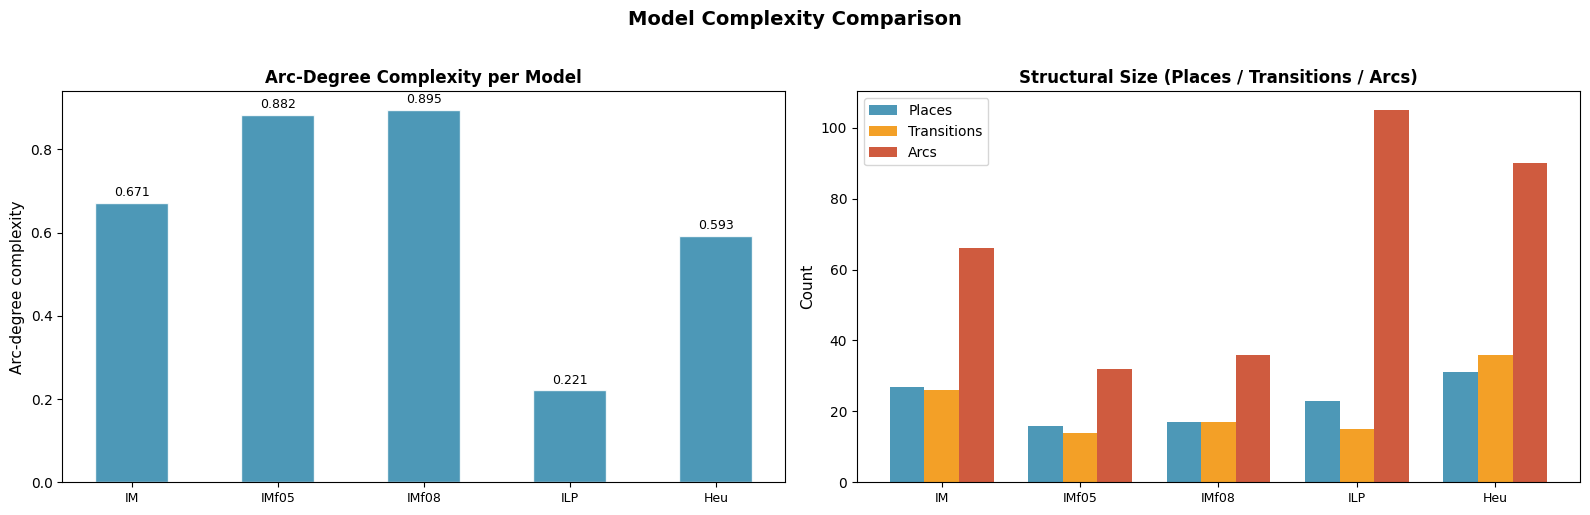

In [94]:
# Visual complexity comparison chart  
model_names = [m[0] for m in models]
arc_vals = [simp_results[m[0]]['arc_degree'] for m in models]
places_c = [len(m[1].places) for m in models]
trans_c = [len(m[1].transitions) for m in models]
arcs_c = [len(m[1].arcs) for m in models]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: arc degree per model 
ax = axes[0]
bars = ax.bar(x, arc_vals, color='#2E86AB', alpha=0.85, edgecolor='white', width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=0, fontsize=9)
ax.set_ylabel('Arc-degree complexity', fontsize=11)
ax.set_title('Arc-Degree Complexity per Model', fontsize=12, fontweight='bold')
for bar, val in zip(bars, arc_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(arc_vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Right: structural counts (places / transitions / arcs)
ax2 = axes[1]
ax2.bar(x - width, places_c, width, label='Places', color='#2E86AB', alpha=0.85)
ax2.bar(x, trans_c, width, label='Transitions', color='#F18F01', alpha=0.85)
ax2.bar(x + width, arcs_c, width, label='Arcs', color='#C73E1D', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=0, fontsize=9)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Structural Size (Places / Transitions / Arcs)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('Model Complexity Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/simplicity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [95]:
# Add simplicity metrics to the summary table
for i, (key, net, im, fm, title) in enumerate(models):
    summary_df.loc[title, 'Arc-degree'] = simp_results[key]['arc_degree']
    summary_df.loc[title, 'Cardoso'] = simp_results[key]['extended_cardoso']
    summary_df.loc[title, 'Cyclomatic'] = simp_results[key]['extended_cyclomatic']
    
print('FINAL SUMMARY TABLE (with complexity metrics)')
summary_df

FINAL SUMMARY TABLE (with complexity metrics)


,Sound,Log Fitness,Avg Trace Fitness,% Fitting Traces,Precision,Places,Transitions,Arcs,Arc-degree,Cardoso,Cyclomatic
Model,,,,,,,,,,,
Inductive Miner (noise=0.0),✓,1.0000,1.0000,100.0%,0.383257,27,26,66,0.670886,29.0,2819.0
IM infrequent (noise=0.5),✓,0.9368,0.9362,42.4%,0.956255,16,14,32,0.882353,16.0,20.0
IM infrequent (noise=0.8),✓,0.8871,0.8862,15.0%,0.969763,17,17,36,0.894737,17.0,19.0
ILP Miner,✗,0.9116,0.9117,0.6%,0.863636,23,15,105,0.220930,53.0,NaN
Heuristics Miner,✗,NaN,NaN,NaN,NaN,31,36,90,0.592920,44.0,12.0


The discovered models show the typical trade-off between fitness, precision, simplicity, and soundness.

The standard Inductive Miner produced a fully sound model with almost perfect fitness, meaning it can replay nearly all traces in the log. However, its low precision and very high complexity indicate overgeneralization and a large, complex model.

The Inductive Miner infrequent variants (noise = 0.5 and 0.8) generated much simpler and more precise models. Increasing the noise threshold improved precision, but reduced fitness and the percentage of perfectly fitting traces, since more infrequent behavior was filtered out.

The ILP Miner achieved relatively high fitness and precision, but the model was not sound. Therefore, these alignment-based metrics are not fully reliable, because unsound nets may contain deadlocks or invalid behavior that affects replay results.

The Heuristics Miner also produced a non-sound model, and alignment-based fitness and precision could not be computed at all. This highlights that soundness is a prerequisite for reliable conformance checking.

### <b>4d.</b> Identifying Imprecisions in the IMf Models
For the Inductive Miner infrequent (IMf) models, identify one behavior (sequence of
activities) allowed by the model that does not make sense and has no actual support
in the data. In other words, point out an imprecision of the model.

#### Custom functions for easier imprecisions search

In [96]:
# Extract activity label from a reachability-graph transition name 
def extract_label(ts_name):
    """
    Parse the activity label from a reachability-graph transition name string.
    Returns the label string for visible transitions, or None for silent ones.
    """
    m = re.search(r",\s*'(.+)'\)", ts_name)
    if m:
        return m.group(1)   # visible transition label
    return None             # silent transition (None in string = tau)

In [97]:
# Enumerate all complete model traces using BFS 
def get_all_model_traces(net, im, fm, max_depth=30, max_traces=2000):
    """
    Enumerate all distinct complete traces allowed by the Petri net
    via BFS over its reachability graph.
    """
    # Build reachability graph
    ts = pm4py.convert_to_reachability_graph(net, im, fm)

    # Build adjacency list: state_name -> [(label_or_None, next_state_name)]
    adj = {}
    for t in ts.transitions:
        label = extract_label(t.name)
        adj.setdefault(t.from_state.name, []).append((label, t.to_state.name))

    # Run BFS to find complete traces from 'source1' to 'sink1'
    # Track visited (state, trace) pairs to avoid looping.
    traces = set()
    queue = deque([('source1', ())])
    visited = set()

    while queue and len(traces) < max_traces:
        sn, trace = queue.popleft()

        key = (sn, trace)
        if key in visited:
            continue
        visited.add(key)

        # Reached the sink = complete trace
        if sn == 'sink1':
            traces.add(trace)
            continue

        # Stop if trace is already too long (catches unbounded loops)
        if len(trace) >= max_depth:
            continue

        for (label, next_sn) in adj.get(sn, []):
            if label is not None:          # visible transition: extend trace
                queue.append((next_sn, trace + (label,)))
            else:                          # silent transition: same trace
                queue.append((next_sn, trace))

    return traces

In [98]:
# Find the most similar log variant (shortest edit distance)
def edit_dist(a, b):
    # Simple Levenshtein distance on tuples
    m, n = len(a), len(b)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = dp[i-1][j-1] if a[i-1]==b[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[m][n]

#### Back to the main question

In [99]:
# Collect log variants for comparison 
log_variants = set(pm4py.get_variants(rejected_loans).keys())

# Enumerate model-allowed traces for both IMf models 
imf_models = [(k, n, i, f, t) for k, n, i, f, t in models if 'infrequent' in t]

model_traces_dict = {}
for key, net, im, fm, title in imf_models:
    
    traces = get_all_model_traces(net, im, fm, max_depth=30, max_traces=2000)
    model_traces_dict[key] = traces
    imprecisions = traces - log_variants

    print(title)
    print(f'  Model traces : {len(traces)}')
    print(f'  Log variants : {len(log_variants)}')
    print(f'  Imprecisions : {len(imprecisions)} traces allowed by model but NOT in log', end='\n\n')

IM infrequent (noise=0.5)
  Model traces : 108
  Log variants : 61
  Imprecisions : 104 traces allowed by model but NOT in log

IM infrequent (noise=0.8)
  Model traces : 70
  Log variants : 61
  Imprecisions : 67 traces allowed by model but NOT in log



In [100]:
# Display the imprecise traces in detail 
for key, net, im, fm, title in imf_models:
    traces = model_traces_dict.get(key)

    imprecisions = traces - log_variants    # model allows but log does NOT have
    print(f'{"=" * 70}')
    print(f'{title}  |  Imprecisions : {len(imprecisions)}')
    print(f'{"=" * 70}')

    # We output few examples per category to keep the notebook readable
    shown = 0
    for tr in list(imprecisions)[:8]:   
        print(f'    {" -> ".join(tr)}')
        shown += 1
    if len(imprecisions) > shown:
        print(f'    ... ({len(imprecisions) - shown} more)')

IM infrequent (noise=0.5)  |  Imprecisions : 104
    Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Confirmed Identity -> Query Central Bank System -> Retrieve Customer Global Risk Score -> Query Credit Bureau -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Send Rejection Notification
    Application Registered -> Retrieve Identity Document -> Verify ID Automatically -> Confirmed Identity -> Retrieve Internal Log Data -> Query Central Bank System -> Query Credit Bureau -> Retrieve Customer Global Risk Score -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Application -> Reject Application -> Reject Application -> Reject Application -> Reject Ap

In [ ]:
# Highlight one imprecision of IMf-0.5 
imf05_traces = model_traces_dict.get('IMf05')
imf05_imprecisions = sorted(imf05_traces - log_variants, key=len)

if imf05_imprecisions:
    example = imf05_imprecisions[-1] 
    print('HIGHLIGHTED IMPRECISION IN IMf-0.5')
    print('=' * 100)

    closest = min(log_variants, key=lambda v: edit_dist(example, v))
    dist    = edit_dist(example, closest)
    
    for i, act in enumerate(example, 1):
        print(f'    Step {i:<2}: {act:<35}', end='')
        if i <= len(closest):
            print(f'      Closest log step: {closest[i-1]}')
        else:
            print()

    print(f'The closest log variant is at an edit distance of {dist}.')

else:
    print('No imprecisions found in IMf-0.5 (all model traces are in the log).')

HIGHLIGHTED IMPRECISION IN IMf-0.5
    Step 1 : Application Registered                   Closest log step: Application Registered
    Step 2 : Retrieve Identity Document               Closest log step: Retrieve Identity Document
    Step 3 : Verify ID Automatically                  Closest log step: Verify ID Automatically
    Step 4 : Retrieve Internal Log Data               Closest log step: Retrieve Internal Log Data
    Step 5 : Confirmed Identity                       Closest log step: Verify ID Manually
    Step 6 : Query Central Bank System                Closest log step: Confirmed Identity
    Step 7 : Retrieve Customer Global Risk Score      Closest log step: Query Central Bank System
    Step 8 : Query Credit Bureau                      Closest log step: Retrieve Customer Global Risk Score
    Step 9 : Retrieve Financial Status                Closest log step: Query Credit Bureau
    Step 10: Create Assessment Report                 Closest log step: Retrieve Financial Statu

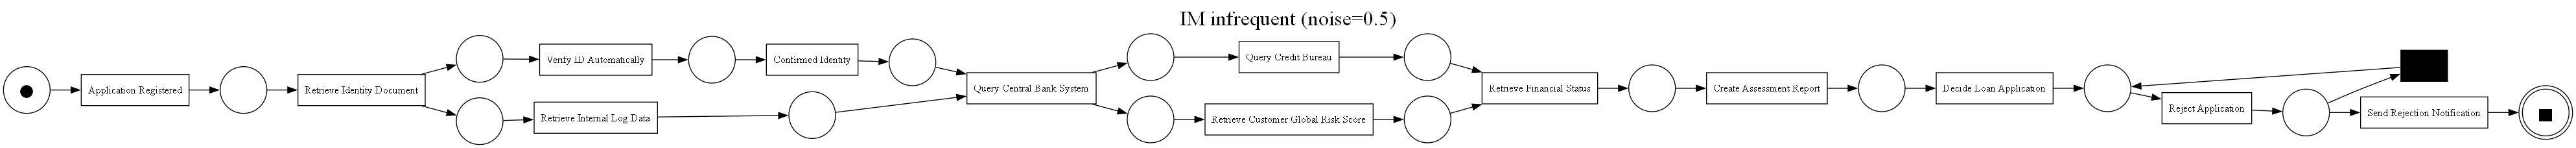

In [102]:
# Take a look again at the IMf-0.5 model
display(Image(filename='images/model_IMf05.png'))

The IMf-0.5 model trace highlighted above shows a critical flaw: an unbounded loop on "Reject Application". When aligning this model trace against the closest matching log variant, the comparison shows that after "Decide Loan Application" fires at step 12, the model continues repeating "Reject Application" for 18 consecutive repetitions, before finally reaching "Send Rejection Notification".

Im it important to remember that a hard limit was set during model trace findings to prevent infinite expansion. Without that cap, the loop would continue indefinitely. This means the IMf-0.5 model technically permits an infinite number of rejections, which clearly does not make sense from a real-world perspective.

### <b>4d.</b> Final Model Comparison
Rank the models based on the results obtained in the above subquestions. For
each model, give your overall impression, and state whether you think it is a useful
model or not. Give at least two reasons for your decision. 

1. **Inductive Miner infrequent (noise = 0.5)**
   This is the best overall compromise between simplicity, precision, and soundness. The model is much smaller and more precise than the standard IM while still remaining sound, although it allows the unrealistic infinite repetition of “Reject Application”, which reduces its practical realism. 

2. **Inductive Miner infrequent (noise = 0.8)**
   This model is the simplest and most precise sound model, making it easy to interpret and less overgeneralized. However, its lower fitness means that much observed behavior is excluded, and it also suffers from the same infinite rejection loop issue.

3. **Inductive Miner – standard (noise = 0.0)**
   The standard IM achieves almost perfect fitness and is sound, but it is extremely complex and heavily overgeneralizes behavior. In addition, it also contains the unrealistic infinite “Reject Application” loop.

4. **ILP Miner**
   The ILP Miner provides relatively strong fitness and precision values, but the model is not sound, making these metrics less trustworthy. Its high complexity and structural issues reduce its usefulness as a reliable process model.

5. **Heuristics Miner**
   This is the weakest model because it is not sound and alignment-based fitness and precision could not be computed. Since the model cannot guarantee correct execution behavior, it is not suitable for dependable conformance analysis.


## <b>Question 5</b>: Conformance Checking